In [4]:
import os
import sys

# Get the absolute path of the directory containing the notebook (notebooks/)
current_dir = os.path.abspath('')

# Add the parent directory (SingleWordProductionDutch/) to the system path
# This allows Python to find 'src'
parent_dir = os.path.dirname(current_dir)
sys.path.append(parent_dir)

import numpy as np
import scipy.signal
from scipy.signal import hilbert
import matplotlib.pyplot as plt
from scipy.signal import welch
from scipy.stats import pearsonr
from pynwb import NWBHDF5IO

import pandas as pd
import numpy.matlib as matlib
import scipy.signal

feat_path = r'./features'
result_path = r'./results'


winL = 0.05
frameshift = 0.01
modelOrder = 4
stepSize = 5
sr=1024
path_bids = '/Users/lisa/Documents/DSAI_year2/Marble/SingleWordProductionDutch/SingleWordProductionDutch-iBIDS'

In [31]:

sr=1024
duration_sec = 2
n_samples = int(duration_sec * sr)
t = np.arange(n_samples) / sr

def get_feat_for_plt(pt, ch_idx):
    hga_stacked = np.load(os.path.join(feat_path,f'{pt}_feat.npy'))
    sspe_stacked = np.load(os.path.join(feat_path,f'{pt}_SSPEfeat.npy'))
    
    feat_hga = hga_stacked[:n_samples, ch_idx].flatten()
    
    somata_results = np.load(os.path.join(path_somata,f'{pt}_somata_results.npy'),allow_pickle=True).item()
    start_col = -1
    for i in range(ch_idx):
        start_col += somata_results[i]['knee_n_osc']
    #i think this is wrong, because we do have zero padding. so then it should be the length of the fixed array*


    
    # The number of oscillators for the current channel
    current_n_osc = somata_results[ch_idx]['knee_n_osc']

    feat_sspe = np.sum(sspe_stacked[:n_samples, start_col : start_col + current_n_osc], axis=1)

    
    # Normalize for visual comparison (z-score) so they sit on top of each other
    feat_hga_norm = (feat_hga - np.mean(feat_hga)) / np.std(feat_hga)

    if np.std(feat_sspe) ==0:
        print(f"std sspe: {np.std(feat_sspe)}, ch_idx: {ch_idx}")
        print('feat sspe ',feat_sspe)
        feat_sspe_norm = feat_sspe
    feat_sspe_norm = (feat_sspe - np.mean(feat_sspe)) / np.std(feat_sspe)

    
    
    #raw data features
    winL = 0.05
    frameshift = 0.01
    modelOrder = 4
    stepSize = 5
    path_bids = '/Users/lisa/Documents/DSAI_year2/Marble/SingleWordProductionDutch/SingleWordProductionDutch-iBIDS'
    io = NWBHDF5IO(os.path.join(path_bids,pt,'ieeg',f'{pt}_task-wordProduction_ieeg.nwb'), 'r')
    nwbfile = io.read()
    data = nwbfile.acquisition['iEEG'].data[:]
    io.close()
    
    #Small helper function to speed up the hilbert transform by extending the length of data to the next power of 2
    hilbert3 = lambda x: scipy.signal.hilbert(x, scipy.fftpack.next_fast_len(len(x)),axis=0)[:len(x)]
    
    numWindows = int(np.floor((data.shape[0]-winL*sr)/(frameshift*sr)))
        
    #Create feature space
    data = np.abs(hilbert3(data))
    feat = np.zeros((numWindows,data.shape[1]))
    for win in range(numWindows):
        start= int(np.floor((win*frameshift)*sr))
        stop = int(np.floor(start+winL*sr))
        feat[win,:] = np.mean(data[start:stop,:],axis=0)
    
    feat_raw = feat[:n_samples, ch_idx]
    
    # Normalize for visual comparison so they sit on top of each other
    feat_raw_norm = (feat_raw - np.mean(feat_raw)) / np.std(feat_raw)
    
    return feat_raw_norm, feat_hga_norm, feat_sspe_norm

channel 96 for participant sub-07:
fit hga to raw
Correlation (r): 0.1253
RMSE:            1.3226
R-squared:       -0.7493

fit sspe to raw
Correlation (r): 0.3143
RMSE:            1.1711
R-squared:       -0.3714



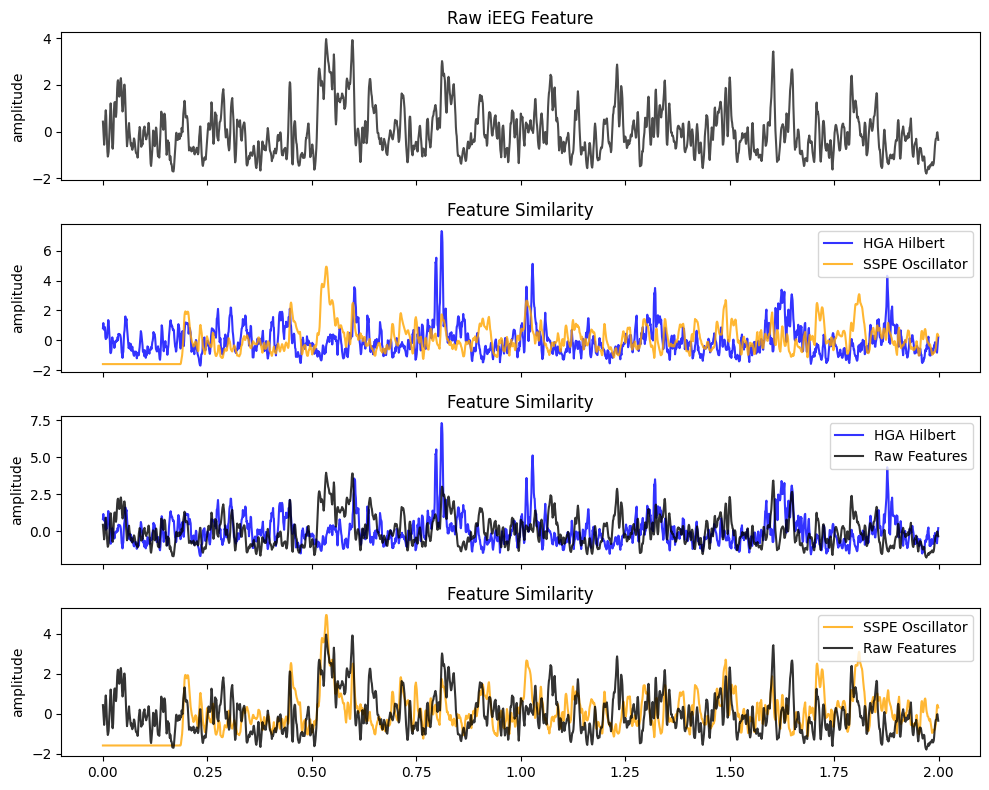

channel 95 for participant sub-07:
fit hga to raw
Correlation (r): 0.0688
RMSE:            1.3647
R-squared:       -0.8623

fit sspe to raw
Correlation (r): 0.0778
RMSE:            1.3581
R-squared:       -0.8444



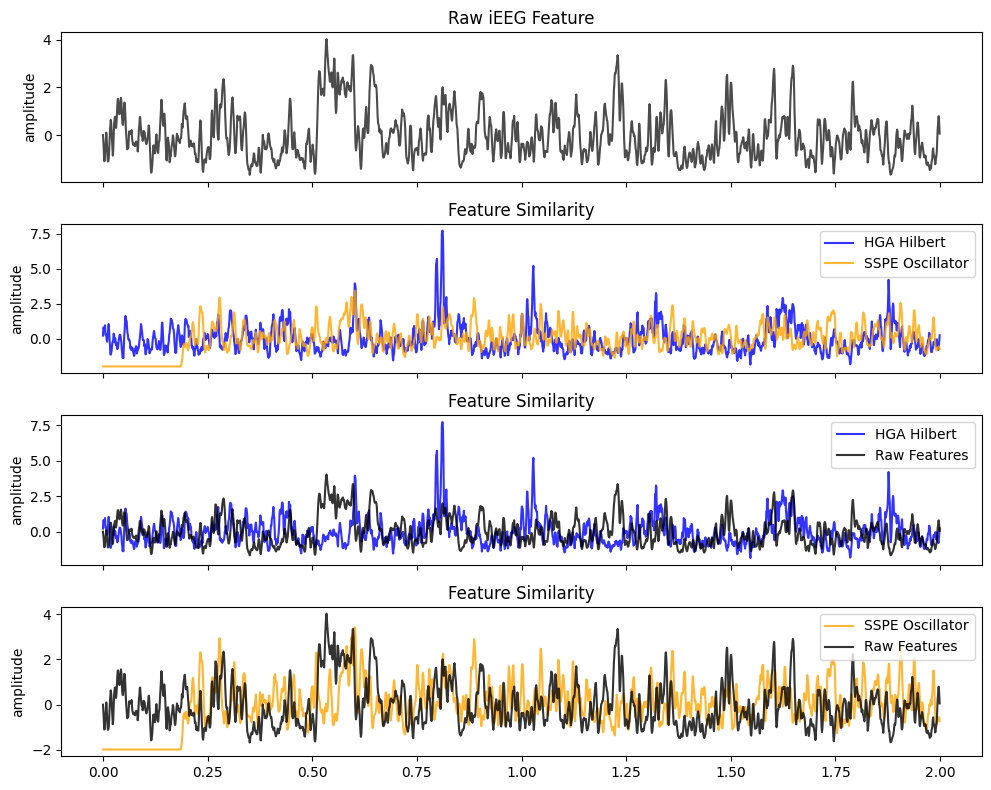

channel 94 for participant sub-07:
fit hga to raw
Correlation (r): 0.0269
RMSE:            1.3951
R-squared:       -0.9462

fit sspe to raw
Correlation (r): 0.2428
RMSE:            1.2306
R-squared:       -0.5145



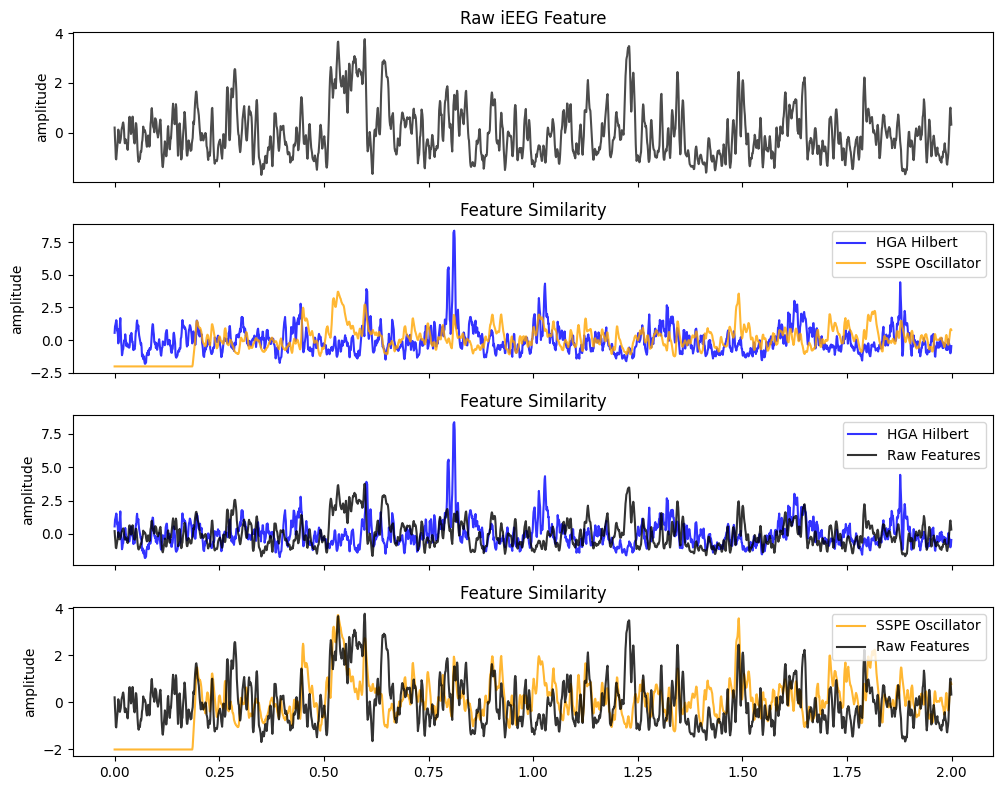

std sspe: 0.0, ch_idx: 97
feat sspe  [0. 0. 0. ... 0. 0. 0.]


/var/folders/y1/645fcb4d13d6kqzpr7g8gbnw0000gp/T/ipykernel_1361/2010266557.py:30: RuntimeWarning: invalid value encountered in divide
  feat_sspe_norm = (feat_sspe - np.mean(feat_sspe)) / np.std(feat_sspe)


channel 97 for participant sub-07:
fit hga to raw
Correlation (r): 0.0820
RMSE:            1.3550
R-squared:       -0.8360



ValueError: array must not contain infs or NaNs

In [32]:
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error
path_somata = '/Users/lisa/Documents/DSAI_year2/SingleWordProductionDutch-1/somata'
pt = 'sub-07'

#ch = [50, 8, 51, 101, 52]
ch = [96, 95, 94, 97, 1] #

for ch_idx in ch:
    feat_raw_norm, feat_hga_norm, feat_sspe_norm = get_feat_for_plt(pt, ch_idx)
    print(f'channel {ch_idx} for participant {pt}:')

    
    # Correlation measures the linear relationship (timing/envelope similarity)
    corr, _ = pearsonr(feat_hga_norm, feat_raw_norm)
    # RMSE measures the absolute difference (fit quality)
    rmse = np.sqrt(mean_squared_error(feat_hga_norm, feat_raw_norm))
    #R-squared
    ss_res = np.sum((feat_raw_norm - feat_hga_norm) ** 2)
    ss_tot = np.sum((feat_raw_norm - np.mean(feat_raw_norm)) ** 2)
    r_sq = 1 - (ss_res / ss_tot)

    print("fit hga to raw")
    print(f'Correlation (r): {corr:.4f}')
    print(f'RMSE:            {rmse:.4f}')
    print(f'R-squared:       {r_sq:.4f}\n')
    


    # now for hga vs raw
    corr, _ = pearsonr(feat_raw_norm, feat_sspe_norm)
    # RMSE measures the absolute difference (fit quality)
    rmse = np.sqrt(mean_squared_error(feat_raw_norm, feat_sspe_norm))
    #R-squared
    ss_res = np.sum((feat_raw_norm - feat_sspe_norm) ** 2)
    ss_tot = np.sum((feat_raw_norm - np.mean(feat_raw_norm)) ** 2)
    r_sq = 1 - (ss_res / ss_tot)

    print("fit sspe to raw")
    print(f'Correlation (r): {corr:.4f}')
    print(f'RMSE:            {rmse:.4f}')
    print(f'R-squared:       {r_sq:.4f}\n')
    
    
    fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
    
    # Top: Raw iEEG Feature (Broadband baseline)
    axes[0].plot(t, feat_raw_norm, color='black', alpha=0.7)
    axes[0].set_title(f'Raw iEEG Feature')
    axes[0].set_ylabel('amplitude')
    
    # Middle: HGA vs SSPE Similarity
    axes[1].plot(t, feat_hga_norm, label='HGA Hilbert', color='blue', alpha=0.8)
    axes[1].plot(t, feat_sspe_norm, label='SSPE Oscillator', color='orange', alpha=0.8)
    axes[1].set_title(f'Feature Similarity')
    axes[1].set_ylabel('amplitude')
    axes[1].legend(loc='upper right')

    # HGA vs raw Similarity
    axes[2].plot(t, feat_hga_norm, label='HGA Hilbert', color='blue', alpha=0.8)
    axes[2].plot(t, feat_raw_norm, label='Raw Features', color='black', alpha=0.8)
    axes[2].set_title(f'Feature Similarity')
    axes[2].set_ylabel('amplitude')
    axes[2].legend(loc='upper right')

    # Middle: raw vs SSPE Similarity
    axes[3].plot(t, feat_sspe_norm, label='SSPE Oscillator', color='orange', alpha=0.8)
    axes[3].plot(t, feat_raw_norm, label='Raw Features', color='black', alpha=0.8)
    axes[3].set_title(f'Feature Similarity')
    axes[3].set_ylabel('amplitude')
    axes[3].legend(loc='upper right')
    
    
    plt.tight_layout()
    plt.show()

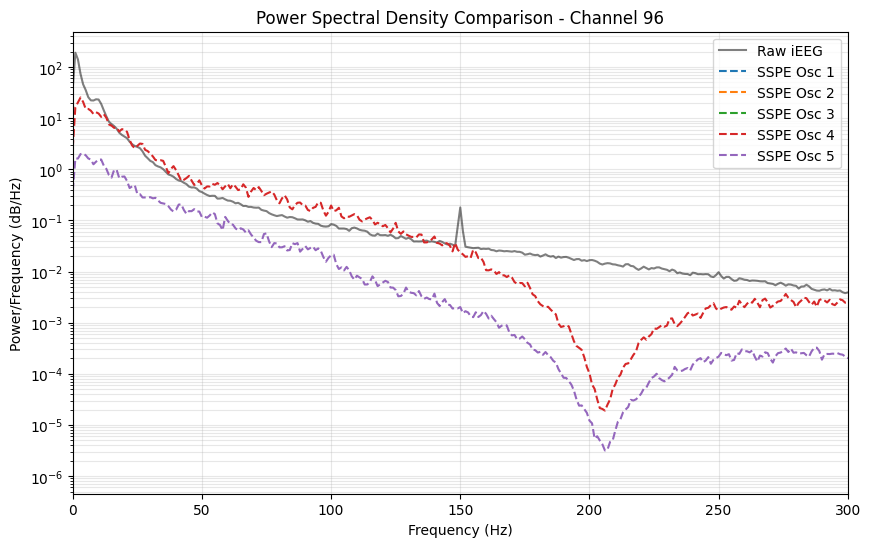

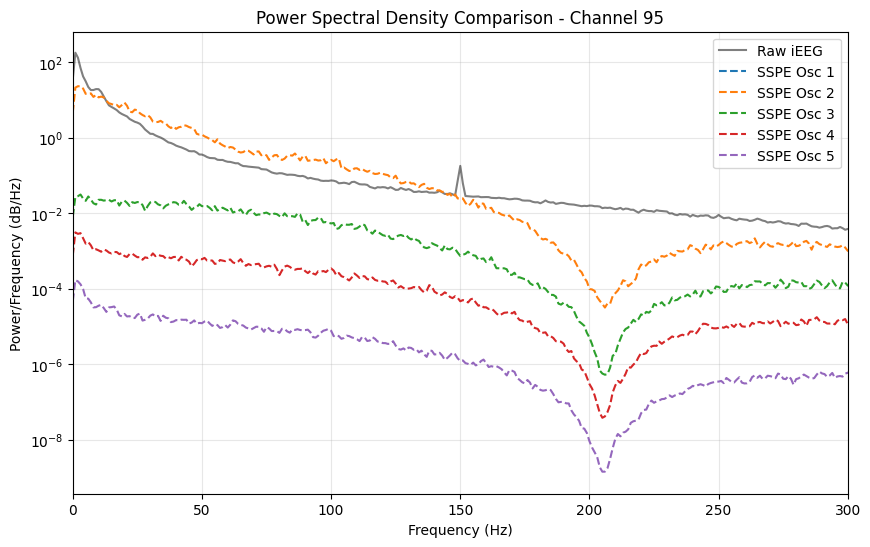

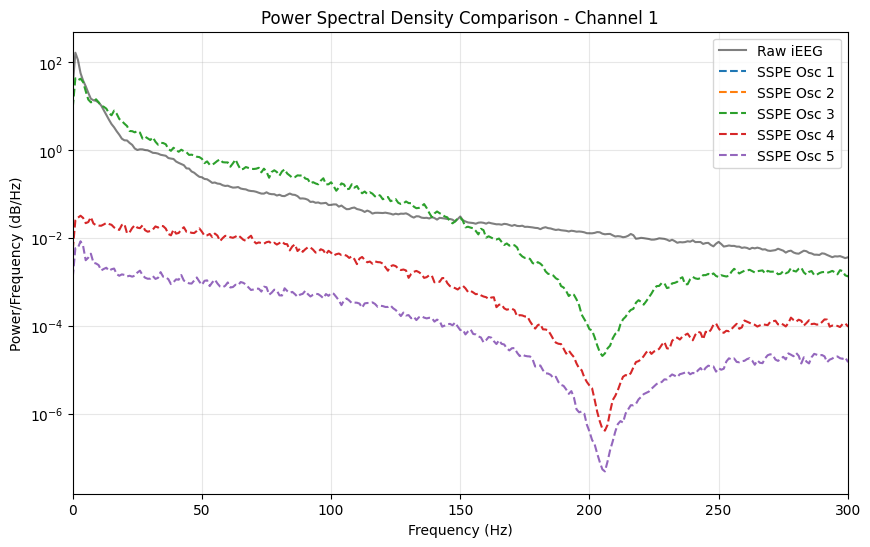

In [9]:

pt = 'sub-07'
ch_idx = 8
#ch = [50, 8, 51, 101]
ch = [96, 95, 1]

path_bids = '/Users/lisa/Documents/DSAI_year2/Marble/SingleWordProductionDutch/SingleWordProductionDutch-iBIDS'
io = NWBHDF5IO(os.path.join(path_bids,pt,'ieeg',f'{pt}_task-wordProduction_ieeg.nwb'), 'r')
nwbfile = io.read()
data = nwbfile.acquisition['iEEG'].data[:]
io.close()

for ch_idx in ch:
    plt.figure(figsize=(10, 6))
        
    # 1. Compute PSD for Raw Signal
    freqs_raw, psd_raw = welch(data[:, ch_idx], sr, nperseg=1024)
    plt.semilogy(freqs_raw, psd_raw, label='Raw iEEG', color='black', alpha=0.5)
    
    # 2. Compute PSD for SSPE Oscillators 
    # (Assuming you have access to the raw oscillations before absolute value)
    # If you only have features, this plot will look like low-frequency noise.
    sspe_stacked = np.load(os.path.join(feat_path,f'{pt}_SSPEfeat.npy'))
    nr_osc = 5
    for i in range(nr_osc):
        osc_data = sspe_stacked[:, ch_idx * nr_osc + i]
        freqs_osc, psd_osc = welch(osc_data, sr, nperseg=1024)
        plt.semilogy(freqs_osc, psd_osc, label=f'SSPE Osc {i+1}', linestyle='--')

    plt.title(f'Power Spectral Density Comparison - Channel {ch_idx}')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Power/Frequency (dB/Hz)')
    plt.xlim([0, 300]) # Focus on the High-Gamma range
    plt.legend()
    plt.grid(True, which='both', alpha=0.3)
    plt.show()

Next steps

1. make plots in viz_find_peaks including all oscillators from somata. ALso look into that weird psd plot, why is amp bigger in osc than in raw signal?? (did i normalize it?  shouldnt normalize it)
2. look into using results somata for 'damping a' and 'sigma2' for initParams SSPE model


3. build automated averaging oscilator paramaters framework
4. implement the rules below

5. Look at time offsets for the speech, make sure I am plotting a bit before and during speech

rule: use knee_osc, if knee_osc + 1 is hg include that too
-for models with knee_osc = 0 or 1: look at ll-plot by hand? or compare logL to minimum/average or other threshold logL?


rule 1
for channels that don't have a HG oscillator: 
1.1 substitude all oscillators with a set of average oscillaters from channels that do have hg
1.2 add an average hg oscillator  from channels that do have hg

rule 2
for all chanels, use set of average 0scillaters from channels that do have hg

rule 3
find in a multivariate way with ml model which channels are useless (with hga feature extraction)
for usefull channels: use rule 1.2
for the useless channels: use rule 2


 
 

using correlation with melspec is not a good way. This is because some channels are only usefull in combination with other channels. those can be VERY informative together, but not on their own. so you need a more sophisticated method for that which evaluates the channels as informative as a set


personal addition: if no hg osc in somata result -> run specparam -> if still no hg result, continue pipeline like above. 

In [ ]:
feat_sspe